In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("zameen-updated.csv")
df.head()


,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


In [2]:
df.shape

(168446, 20)

In [3]:
df.columns

Index(['property_id', 'location_id', 'page_url', 'property_type', 'price',
       'location', 'city', 'province_name', 'latitude', 'longitude', 'baths',
       'area', 'purpose', 'bedrooms', 'date_added', 'agency', 'agent',
       'Area Type', 'Area Size', 'Area Category'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [5]:
df = df.drop([
    'property_id',
    'page_url',
    'date_added',
    'agency',
    'agent',
    'latitude','longitude','purpose','location_id','province_name','Area Type','Area Category'
], axis=1)

In [6]:
df.head()

,property_type,price,location,city,baths,area,bedrooms,Area Size
0,Flat,10000000,G-10,Islamabad,2,4 Marla,2,4.0
1,Flat,6900000,E-11,Islamabad,3,5.6 Marla,3,5.6
2,House,16500000,G-15,Islamabad,6,8 Marla,5,8.0
3,House,43500000,Bani Gala,Islamabad,4,2 Kanal,4,2.0
4,House,7000000,DHA Defence,Islamabad,3,8 Marla,3,8.0


In [7]:
df.isnull().sum()

property_type    0
price            0
location         0
city             0
baths            0
area             0
bedrooms         0
Area Size        0
dtype: int64

In [8]:
df=df.dropna()
df.dtypes
df.shape

(168446, 8)

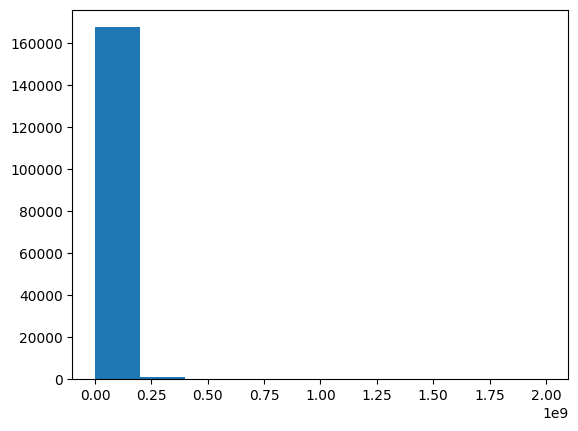

In [9]:
plt.hist(df['price'])
plt.show()

In [10]:
df = df[df['price'] < df['price'].quantile(0.99)]
df.shape

(166686, 8)

In [11]:
# CHANGED: convert area to numeric sqft using Area Size (already numeric)
# Kanal rows get multiplied by 20 to convert to Marla, then * 225 for sqft
def to_sqft(row):
    size = row['Area Size']
    area_str = str(row['area'])
    if 'Kanal' in area_str:
        size = size * 20
    return size * 225

df['area_sqft'] = df.apply(to_sqft, axis=1)
df = df.drop(['area', 'Area Size'], axis=1)
df = df.dropna(subset=['area_sqft'])

In [12]:
# CHANGED: remove junk data - prices below 500k are clearly errors/rentals
# (data had prices like 0, 1, 3, 4 which destroy the model)
df = df[df['price'] >= 500000]

# Also remove junk area values
df = df[df['area_sqft'] > 0]
df = df[df['area_sqft'] < df['area_sqft'].quantile(0.99)]

# Remove zero baths/bedrooms (bad data)
df = df[df['baths'] > 0]
df = df[df['bedrooms'] > 0]

print(df.shape)

(91478, 7)


In [13]:
features = ['city', 'location','property_type', 'area_sqft', 'bedrooms', 'baths']
target   = 'price'

df = df[features + [target]].dropna()

In [14]:
df = df.dropna()

In [15]:
df.shape

(91478, 7)

In [16]:
# CHANGED: split FIRST before any encoding (prevents data leakage)
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = np.log1p(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
# CHANGED: mean encode location using ONLY train data (no leakage)
loc_mean = y_train.groupby(X_train['location']).mean()

X_train = X_train.copy()
X_test = X_test.copy()

X_train['location_encoded'] = X_train['location'].map(loc_mean).fillna(y_train.mean())
X_test['location_encoded'] = X_test['location'].map(loc_mean).fillna(y_train.mean())

X_train = X_train.drop('location', axis=1)
X_test = X_test.drop('location', axis=1)

In [18]:
# CHANGED: only city and property_type get one-hot encoded (location already handled)
X_train = pd.get_dummies(X_train, columns=['city', 'property_type'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['city', 'property_type'], drop_first=True)

# align columns in case test is missing any category
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
score = model.score(X_test, y_test)

print(score)

0.5830572091686106


In [22]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5
)

print(scores)
print(scores.mean())

[0.69275153 0.6795427  0.69250217 0.67558968 0.68655433]
0.6853880797968133


In [23]:
import joblib

joblib.dump(model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']